# Dorsal Hand Vein CNN — Biometric Verification System
**Runtime → Change runtime type → T4 GPU before running any cell.**

Run cells in order. Each cell is safe to re-run — it checks Drive for existing outputs and skips already-completed work.

In [ ]:
# ============================================================
# CELL 1 — Mount Drive, install dependencies, set all paths
# ============================================================

# --- Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Install dependencies ---
import subprocess
subprocess.run(['pip', 'install', '-q', 'scikit-image'], check=True)
print('scikit-image installed.')

# --- Imports ---
import os
import re
import json
import random
import time
import pathlib

import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms.functional as TF
from PIL import Image

from sklearn.metrics import roc_curve, auc, accuracy_score
from scipy import ndimage
from skimage import filters as skfilters

# --- Reproducibility ---
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# --- Paths ---
OUTPUT_ROOT    = '/content/drive/MyDrive/HandVein_Project'
DATASET_ROOT   = '/content/drive/MyDrive/HandVein_Project/dorsalhandveins'
PROCESSED_DIR  = f'{OUTPUT_ROOT}/processed'
STRUCTURED_DIR = f'{OUTPUT_ROOT}/dataset_structured'
MODELS_DIR     = f'{OUTPUT_ROOT}/models'
RESULTS_DIR    = f'{OUTPUT_ROOT}/results'
OUTPUT_SIZE    = (128, 128)

# --- Create directories ---
for d in [OUTPUT_ROOT, PROCESSED_DIR, STRUCTURED_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f'  ✓ {d}')

print('\n[Cell 1 complete] All paths set and directories created.')
print('Next: Run Cell 2 to download the dataset.')

Mounted at /content/drive
scikit-image installed.
Device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB
  ✓ /content/drive/MyDrive/HandVein_Project
  ✓ /content/drive/MyDrive/HandVein_Project/processed
  ✓ /content/drive/MyDrive/HandVein_Project/dataset_structured
  ✓ /content/drive/MyDrive/HandVein_Project/models
  ✓ /content/drive/MyDrive/HandVein_Project/results

[Cell 1 complete] All paths set and directories created.
Next: Run Cell 2 to download the dataset.


In [ ]:
# ============================================================
# CELL 2 — Download dataset (Updated with absolute paths)
# ============================================================

# Ensure the DB paths match the exact case-sensitive folder names in Drive
DB1_DIR = os.path.join(DATASET_ROOT, 'DorsalHandVeins_DB1_png')
DB2_DIR = os.path.join(DATASET_ROOT, 'DorsalHandVeins_DB2_png')

def count_images(folder):
    if not os.path.isdir(folder):
        return 0
    return len([f for f in os.listdir(folder) if f.lower().endswith('.png')])

db1_count = count_images(DB1_DIR)
db2_count = count_images(DB2_DIR)

# If paths are wrong or empty, attempt an absolute fallback verification
if db1_count == 0 or db2_count == 0:
    fallback_root = '/content/drive/MyDrive/HandVein_Project/dorsalhandveins'
    DB1_DIR = os.path.join(fallback_root, 'DorsalHandVeins_DB1')
    DB2_DIR = os.path.join(fallback_root, 'DorsalHandVeins_DB2')
    db1_count = count_images(DB1_DIR)
    db2_count = count_images(DB2_DIR)

if db1_count >= 1000 and db2_count >= 600:
    print(f'Dataset verified and ready.')
    print(f'  DB1: {DB1_DIR} — {db1_count} images')
    print(f'  DB2: {DB2_DIR} — {db2_count} images')
else:
    print('Dataset directories appear empty. Cloning repository to reset structure...')
    os.chdir(OUTPUT_ROOT)
    # Clone directly into OUTPUT_ROOT to match your structure
    !git clone https://github.com/wilchesf/dorsalhandveins.git
    db1_count = count_images(DB1_DIR)
    db2_count = count_images(DB2_DIR)
    print(f'\nDownload/Clone operational complete.')

# --- Final Check & Report ---
print(f'\nDB1 final target path: {DB1_DIR}')
print(f'  Images found: {db1_count} (expected 1104)')
print(f'DB2 final target path: {DB2_DIR}')
print(f'  Images found: {db2_count} (expected 678)')

if db1_count > 0:
    # --- Sample filenames ---
    print('\nSample DB1 filenames:')
    for f in sorted(os.listdir(DB1_DIR))[:5]:
        print(f'  {f}')

    # --- Raw image shape ---
    sample_path = os.path.join(DB1_DIR, sorted(os.listdir(DB1_DIR))[0])
    sample_img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    if sample_img is not None:
        print(f'\nRaw image shape (H×W): {sample_img.shape}')
        print(f'Dtype: {sample_img.dtype}, Min: {sample_img.min()}, Max: {sample_img.max()}')
    else:
        print('\nWarning: Could not read sample image with OpenCV.')
else:
    print('\nCritical Error: DB1 directory is still resolving to 0 images. Please refresh your Drive connection.')

print('\n[Cell 2 complete] Setup verified.')

Dataset verified and ready.
  DB1: /content/drive/MyDrive/HandVein_Project/dorsalhandveins/DorsalHandVeins_DB1_png — 1104 images
  DB2: /content/drive/MyDrive/HandVein_Project/dorsalhandveins/DorsalHandVeins_DB2_png — 678 images

DB1 final target path: /content/drive/MyDrive/HandVein_Project/dorsalhandveins/DorsalHandVeins_DB1_png
  Images found: 1104 (expected 1104)
DB2 final target path: /content/drive/MyDrive/HandVein_Project/dorsalhandveins/DorsalHandVeins_DB2_png
  Images found: 678 (expected 678)

Sample DB1 filenames:
  person_001_db1_L1.png
  person_001_db1_L2.png
  person_001_db1_L3.png
  person_001_db1_L4.png
  person_001_db1_R1.png

Raw image shape (H×W): (560, 752)
Dtype: uint8, Min: 0, Max: 226

[Cell 2 complete] Setup verified.


In [ ]:
# ============================================================
# CELL 3 — ROI extraction and preprocessing pipeline functions
# ============================================================
# Functions are defined here. No images are processed yet.

from skimage.filters import frangi

# ------------------------------------------------------------------
# Function 1: Largest inscribed circle via distance transform
# ------------------------------------------------------------------
def get_largest_inscribed_circle(mask):
    """
    Find the largest circle that fits entirely inside the hand mask.
    Uses the distance transform: each pixel value = distance to nearest
    background pixel. The peak is the circle centre; its value is the radius.
    Returns (cx, cy, radius) as integers.
    """
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _, radius, _, center = cv2.minMaxLoc(dist)
    return int(center[0]), int(center[1]), int(radius)


# ------------------------------------------------------------------
# Function 2: Square ROI extraction (inscribed circle method)
# ------------------------------------------------------------------
def extract_square_roi(gray, debug=False):
    """
    Core ROI extraction. Crops a SQUARE (not a circle) from the largest
    inscribed circle to eliminate black corner artifacts.

    The largest square inscribed in a circle of radius r has
    half-side = r / sqrt(2) = r * 0.7071.

    Returns:
      debug=False: (roi, (cx, cy, radius, half_s), success)
      debug=True:  (roi, (cx, cy, radius, half_s), success, debug_dict)
    """
    h, w = gray.shape

    # Step 1: Blur to reduce noise before thresholding
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Step 2: Otsu threshold → binary hand mask
    _, binary = cv2.threshold(blurred, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Step 3: Morphological closing to fill inter-finger gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)

    # Step 4: Largest contour → solid hand mask
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return (None, None, False, {}) if debug else (None, None, False)

    largest = max(contours, key=cv2.contourArea)
    hand_mask = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(hand_mask, [largest], -1, 255, thickness=cv2.FILLED)

    # Step 5: Largest inscribed circle
    cx, cy, radius = get_largest_inscribed_circle(hand_mask)

    # Validate radius is meaningful
    if radius < min(h, w) // 8:
        return (None, None, False, {}) if debug else (None, None, False)

    # Step 6: Largest inscribed square from the circle
    half_s = int(radius * 0.7071)

    # Step 7: Crop square from original grayscale (raw pixel values)
    x1 = max(0, cx - half_s)
    y1 = max(0, cy - half_s)
    x2 = min(w, cx + half_s)
    y2 = min(h, cy + half_s)

    crop = gray[y1:y2, x1:x2]
    if crop.size == 0:
        return (None, None, False, {}) if debug else (None, None, False)

    # Step 8: Resize to OUTPUT_SIZE
    roi = cv2.resize(crop, OUTPUT_SIZE, interpolation=cv2.INTER_LANCZOS4)

    if debug:
        debug_dict = {
            'binary': binary,
            'closed': closed,
            'hand_mask': hand_mask,
            'cx': cx, 'cy': cy, 'radius': radius, 'half_s': half_s,
            'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2
        }
        return roi, (cx, cy, radius, half_s), True, debug_dict

    return roi, (cx, cy, radius, half_s), True


# ------------------------------------------------------------------
# Function 3: Black-hat vein enhancement (primary CNN input)
# ------------------------------------------------------------------
def enhance_blackhat(roi):
    """
    Extracts dark vein structures as bright features using morphological
    black-hat transform. Veins in NIR images are dark on bright background;
    black-hat highlights dark structures smaller than the kernel.
    """
    # CLAHE to normalise illumination variation
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe.apply(roi)

    # Black-hat: large ellipse kernel to capture vein width
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
    blackhat = cv2.morphologyEx(equalized, cv2.MORPH_BLACKHAT, kernel)

    # Smooth high-frequency noise
    smoothed = cv2.GaussianBlur(blackhat, (5, 5), 0)

    # Normalize to full 0-255 range
    result = cv2.normalize(smoothed, None, 0, 255, cv2.NORM_MINMAX)
    return result.astype(np.uint8)


# ------------------------------------------------------------------
# Function 4: Frangi vesselness filter (secondary channel)
# ------------------------------------------------------------------
def enhance_frangi(roi):
    """
    Frangi vesselness filter detects tubular structures (veins).
    Returns enhanced image highlighting thin tubular vein segments.
    """
    # Normalise to float [0, 1]
    img_f = roi.astype(np.float32) / 255.0

    # Frangi filter: tuned for vein structures
    vessel = frangi(img_f, sigmas=range(2, 5),
                    alpha=0.5, beta=0.5, gamma=15, black_ridges=True)

    # Normalize to 0-255
    if vessel.max() > 0:
        vessel = (vessel / vessel.max() * 255).astype(np.uint8)
    else:
        vessel = np.zeros_like(roi, dtype=np.uint8)

    # CLAHE post-processing to improve contrast
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
    result = clahe.apply(vessel)
    return result


# ------------------------------------------------------------------
# Function 5: Full image processing pipeline
# ------------------------------------------------------------------
def process_image(img_path):
    """
    Load a grayscale NIR image, extract ROI, apply both enhancements.
    Returns dict with keys: roi, blackhat, frangi
    Returns None on failure.
    """
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        print(f'  WARNING: could not load {img_path}')
        return None

    roi, params, success = extract_square_roi(gray, debug=False)
    if not success or roi is None:
        return None

    bh = enhance_blackhat(roi)
    fr = enhance_frangi(roi)

    return {'roi': roi, 'blackhat': bh, 'frangi': fr}


print('All preprocessing functions defined:')
print('  ✓ get_largest_inscribed_circle')
print('  ✓ extract_square_roi')
print('  ✓ enhance_blackhat')
print('  ✓ enhance_frangi')
print('  ✓ process_image')
print('\n[Cell 3 complete] Functions defined. No images processed yet.')
print('Next: Run Cell 4 for QA check on 6 random images.')

All preprocessing functions defined:
  ✓ get_largest_inscribed_circle
  ✓ extract_square_roi
  ✓ enhance_blackhat
  ✓ enhance_frangi
  ✓ process_image

[Cell 3 complete] Functions defined. No images processed yet.
Next: Run Cell 4 for QA check on 6 random images.


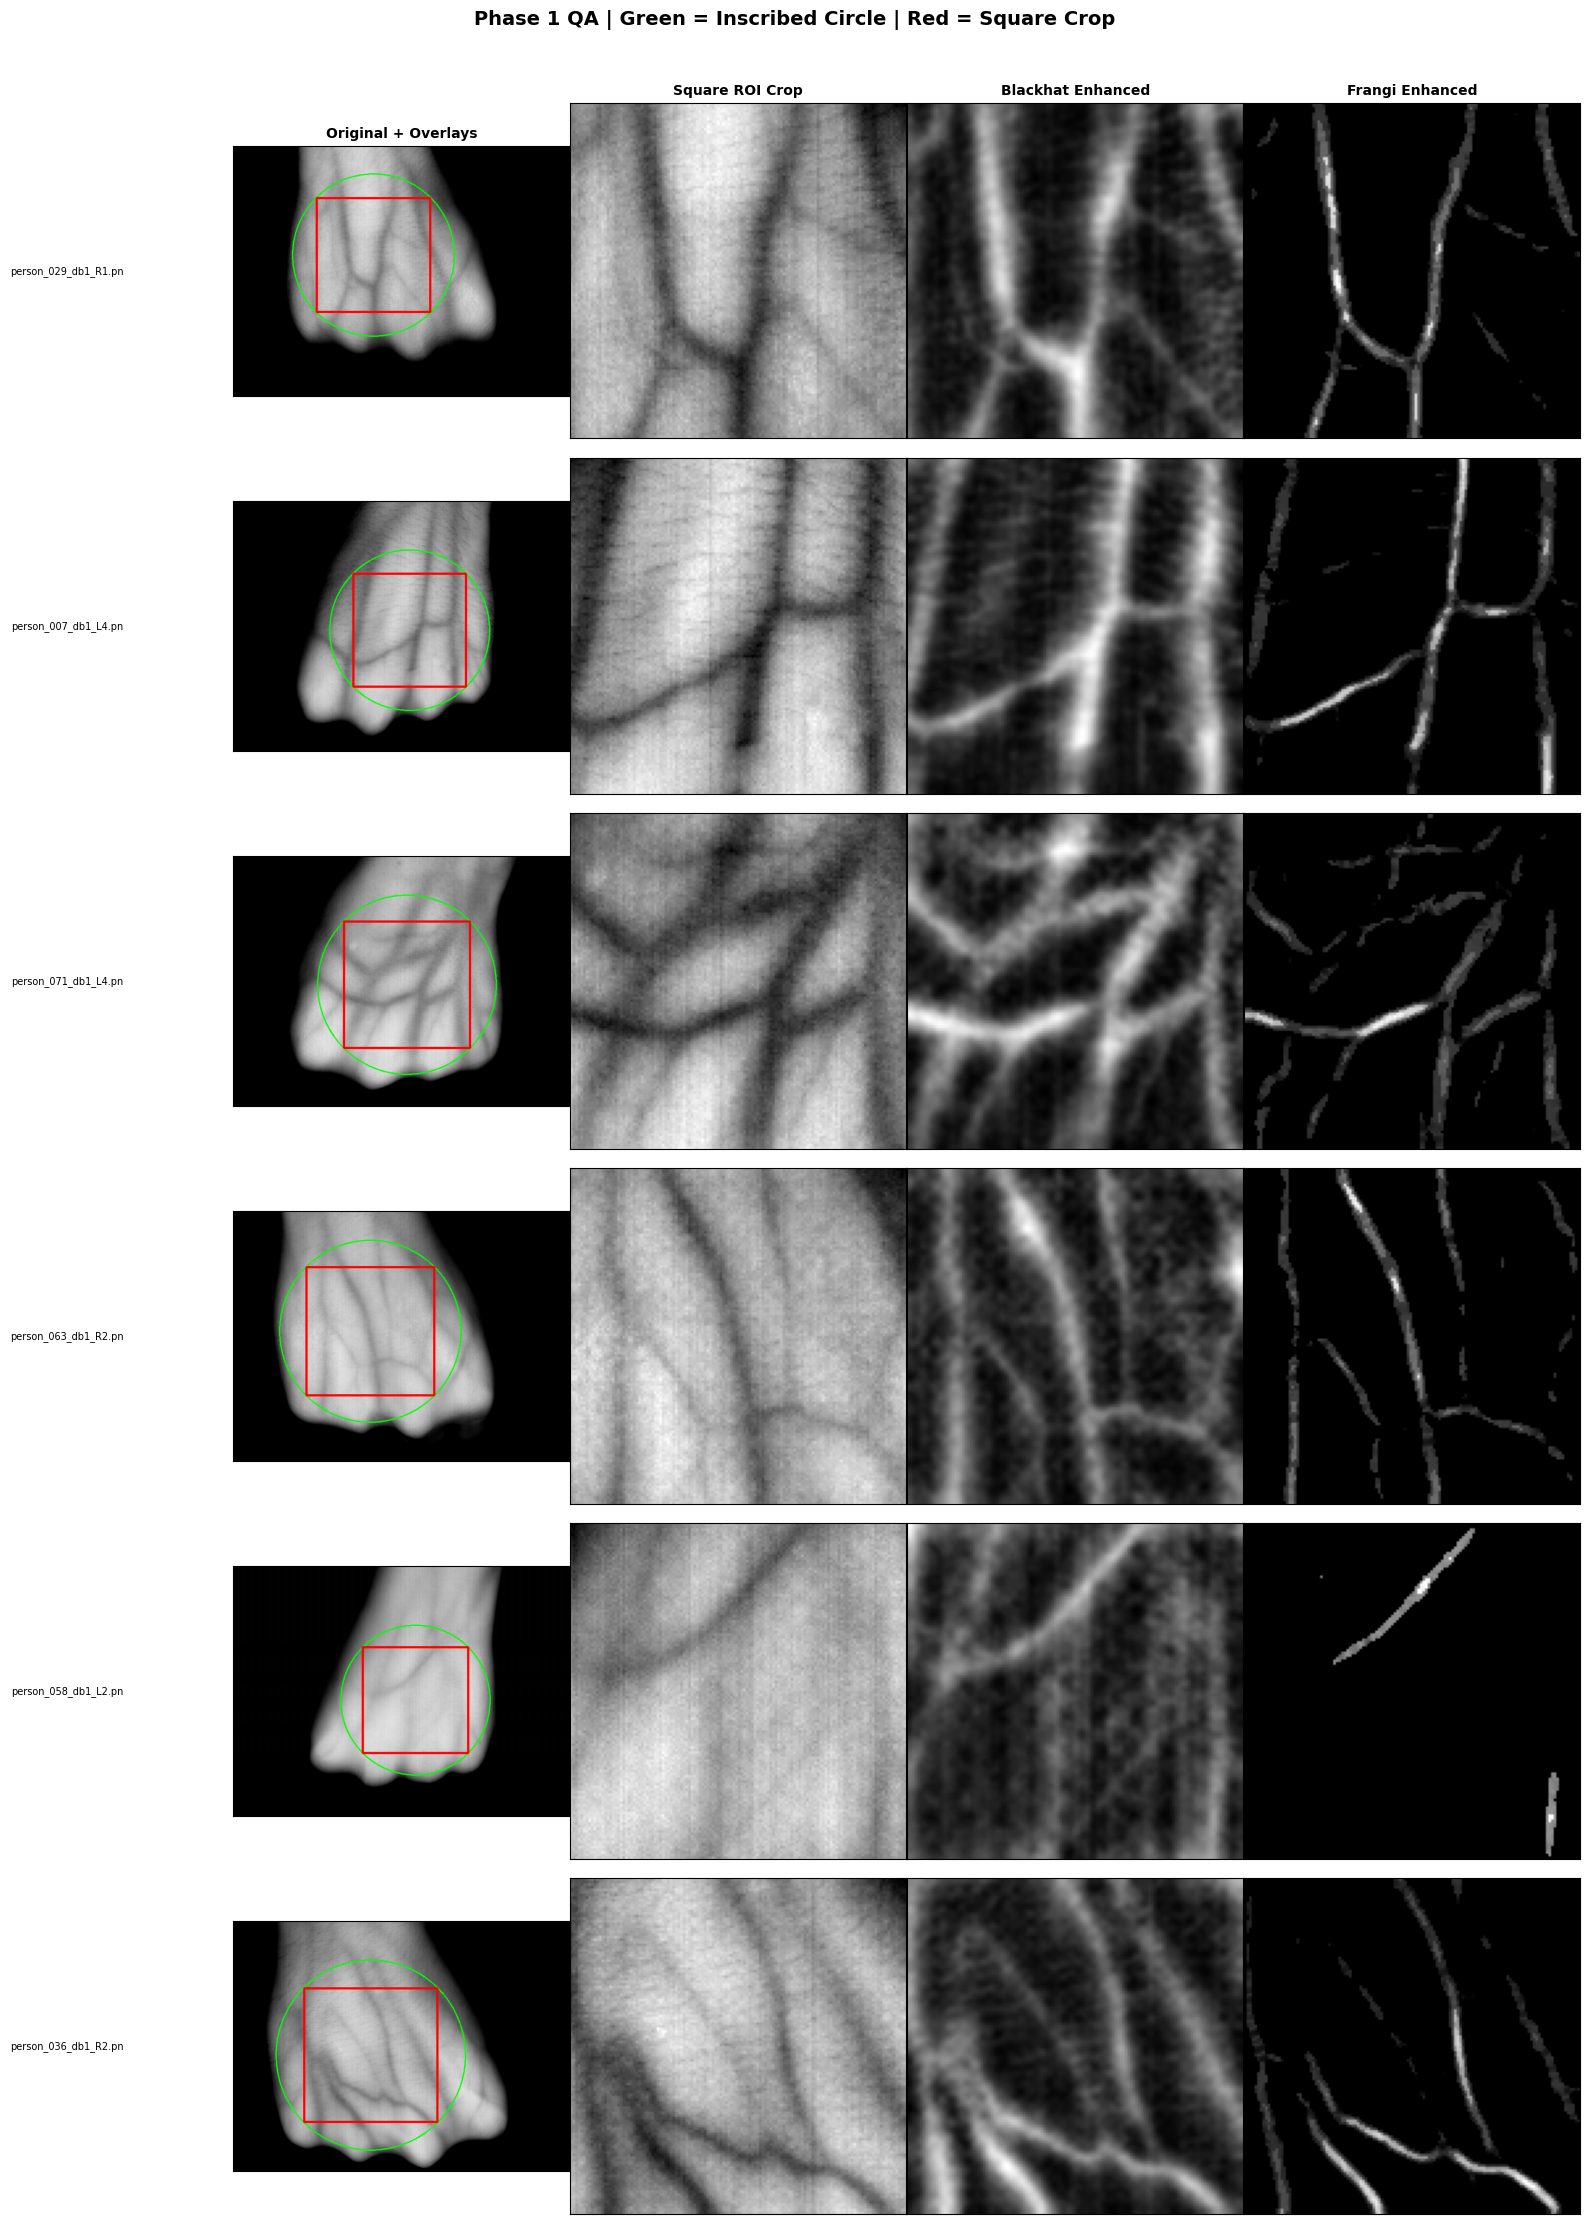

QA plot saved to: /content/drive/MyDrive/HandVein_Project/results/phase1_qa.png

--- QA Checklist ---
✓ Red square sits completely inside hand skin with zero black corners?
✓ Square ROI shows clear vein patterns?
✓ Blackhat shows bright branching vein structures?
✓ Frangi shows thin tubular vein segments?

  ⚠  STOP HERE AND INSPECT THE PLOT BEFORE RUNNING CELL 5  ⚠

[Cell 4 complete] QA visualization saved.
Next: IF the plot looks correct, run Cell 5 to process all 1782 images.


In [ ]:
# ============================================================
# CELL 4 — QA check on 6 random images before full processing
# ============================================================
# INSPECT THIS PLOT CAREFULLY BEFORE RUNNING CELL 5.

db1_files = sorted([f for f in os.listdir(DB1_DIR) if f.lower().endswith('.png')])
random.seed(RANDOM_SEED)
sample_files = random.sample(db1_files, 6)

fig, axes = plt.subplots(6, 4, figsize=(16, 22))
fig.suptitle('Phase 1 QA | Green = Inscribed Circle | Red = Square Crop',
             fontsize=14, fontweight='bold', y=1.01)

col_labels = ['Original + Overlays', 'Square ROI Crop', 'Blackhat Enhanced', 'Frangi Enhanced']
for ax, label in zip(axes[0], col_labels):
    ax.set_title(label, fontsize=10, fontweight='bold')

for row_idx, fname in enumerate(sample_files):
    img_path = os.path.join(DB1_DIR, fname)
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    roi, params, success, dbg = extract_square_roi(gray, debug=True)

    # Column 0: original with overlays
    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    if success:
        cx, cy, radius, half_s = params
        # Green inscribed circle
        cv2.circle(overlay, (cx, cy), radius, (0, 255, 0), 2)
        # Red square crop bounds
        x1 = max(0, cx - half_s)
        y1 = max(0, cy - half_s)
        x2 = min(gray.shape[1], cx + half_s)
        y2 = min(gray.shape[0], cy + half_s)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 0, 255), 3)

    axes[row_idx, 0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[row_idx, 0].set_ylabel(fname[:20], fontsize=7, rotation=0,
                                 labelpad=120, va='center')

    # Column 1: Square ROI
    if success and roi is not None:
        axes[row_idx, 1].imshow(roi, cmap='gray')
        bh = enhance_blackhat(roi)
        fr = enhance_frangi(roi)
        # Column 2: Blackhat
        axes[row_idx, 2].imshow(bh, cmap='gray')
        # Column 3: Frangi
        axes[row_idx, 3].imshow(fr, cmap='gray')
    else:
        for c in range(1, 4):
            axes[row_idx, c].text(0.5, 0.5, 'FAILED', ha='center',
                                  va='center', color='red', transform=axes[row_idx, c].transAxes)

    for c in range(4):
        axes[row_idx, c].set_xticks([])
        axes[row_idx, c].set_yticks([])

plt.tight_layout()
qa_path = os.path.join(RESULTS_DIR, 'phase1_qa.png')
plt.savefig(qa_path, dpi=110, bbox_inches='tight')
plt.show()
print(f'QA plot saved to: {qa_path}')

print('\n--- QA Checklist ---')
print('✓ Red square sits completely inside hand skin with zero black corners?')
print('✓ Square ROI shows clear vein patterns?')
print('✓ Blackhat shows bright branching vein structures?')
print('✓ Frangi shows thin tubular vein segments?')
print()
print('=' * 60)
print('  ⚠  STOP HERE AND INSPECT THE PLOT BEFORE RUNNING CELL 5  ⚠')
print('=' * 60)
print('\n[Cell 4 complete] QA visualization saved.')
print('Next: IF the plot looks correct, run Cell 5 to process all 1782 images.')

Loaded existing manifest: 1782 records.
Total files to process: 1782

Manifest saved: /content/drive/MyDrive/HandVein_Project/manifest.json (1782 records)

Structured dataset summary:
  Total class folders : 276 (expected 276)
  Images per class    : min=4, max=4, mean=4.0

Processing summary:
  Processed  : 0
  Failed     : 0
  Skipped    : 1782


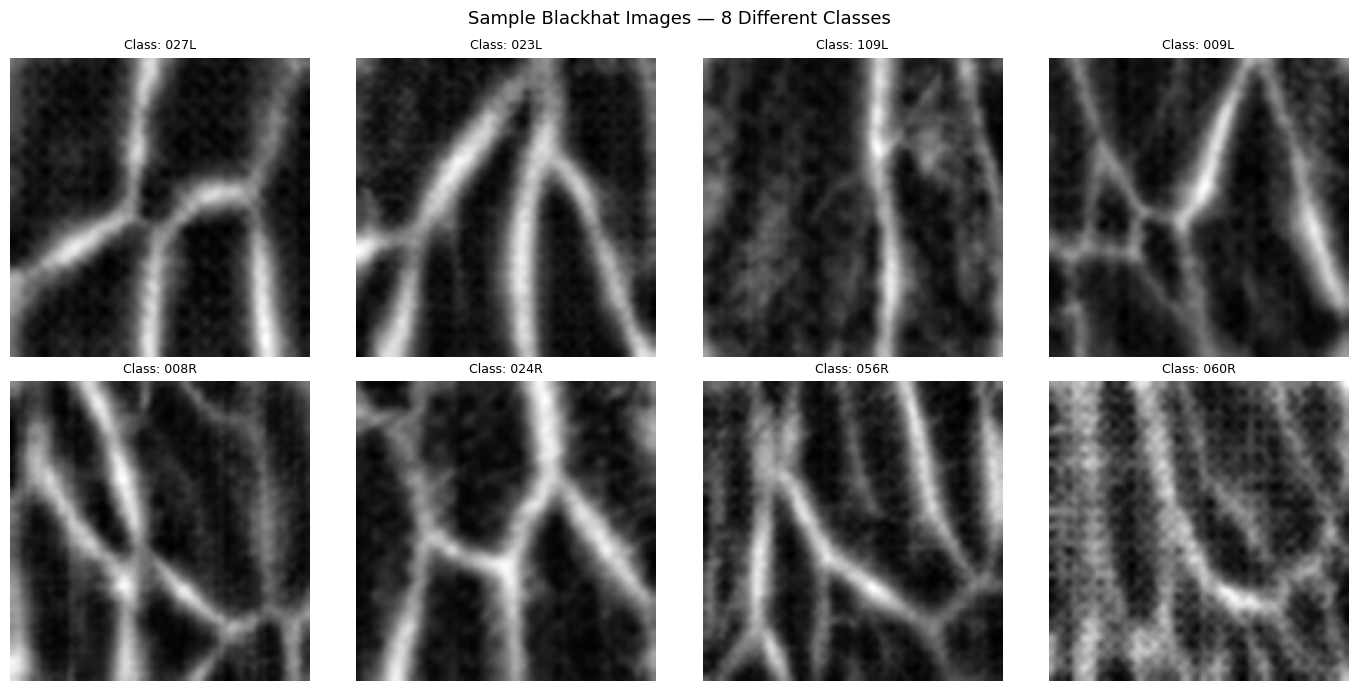


[Cell 5 complete] All images processed and structured dataset built.
  Structured dir : /content/drive/MyDrive/HandVein_Project/dataset_structured
  Manifest       : /content/drive/MyDrive/HandVein_Project/manifest.json
Next: Run Cell 6 to define train/test split and DataLoaders.


In [ ]:
# ============================================================
# CELL 5 — Process all 1782 images and build structured dataset
# ============================================================
# Resumable — skips images already processed. Safe to re-run.

# ------------------------------------------------------------------
# Part A: Filename parser
# ------------------------------------------------------------------
def parse_filename(fname, db):
    """
    Parse person_001_db1_L1.png → (person_id='001', hand='L', session='1')
    Returns (None, None, None) on failure.
    """
    pattern = r'person_(\d+)_db\d+_([LR])(\d+)\.png'
    m = re.match(pattern, fname, re.IGNORECASE)
    if m:
        return m.group(1), m.group(2).upper(), m.group(3)
    return None, None, None


# ------------------------------------------------------------------
# Part B: Processing loop
# ------------------------------------------------------------------
manifest = []
manifest_path = os.path.join(OUTPUT_ROOT, 'manifest.json')

# Load existing manifest to support resume
existing_blackhats = set()
if os.path.exists(manifest_path):
    with open(manifest_path, 'r') as f:
        manifest = json.load(f)
    existing_blackhats = {r['blackhat_path'] for r in manifest}
    print(f'Loaded existing manifest: {len(manifest)} records.')

db_configs = [
    (1, DB1_DIR),
    (2, DB2_DIR),
]

total_processed = 0
total_failed = 0
total_skipped = 0
start_time = time.time()
all_files = []

for db_num, db_dir in db_configs:
    for fname in sorted(os.listdir(db_dir)):
        if fname.lower().endswith('.png'):
            all_files.append((db_num, db_dir, fname))

print(f'Total files to process: {len(all_files)}')

for idx, (db_num, db_dir, fname) in enumerate(all_files):
    pid, hand, session = parse_filename(fname, db_num)
    if pid is None:
        total_failed += 1
        continue

    base = os.path.splitext(fname)[0]
    class_label = f'{pid}{hand}'  # e.g. '001L'

    # Processed output paths
    proc_folder = os.path.join(PROCESSED_DIR, f'db{db_num}', f'person_{pid}')
    os.makedirs(proc_folder, exist_ok=True)
    blackhat_path  = os.path.join(proc_folder, f'{base}_blackhat.png')
    roi_path       = os.path.join(proc_folder, f'{base}_roi.png')
    frangi_path    = os.path.join(proc_folder, f'{base}_frangi.png')

    # Structured path for CNN training
    struct_folder = os.path.join(STRUCTURED_DIR, class_label)
    os.makedirs(struct_folder, exist_ok=True)
    struct_path = os.path.join(struct_folder, f'{class_label}{session}.png')

    # Resume check
    if os.path.exists(blackhat_path) and os.path.exists(struct_path):
        # Add to manifest if not already there
        if blackhat_path not in existing_blackhats:
            manifest.append({
                'person': pid, 'hand': hand, 'session': session,
                'db': db_num, 'class_label': class_label,
                'blackhat_path': blackhat_path,
                'roi_path': roi_path,
                'frangi_path': frangi_path,
                'struct_path': struct_path
            })
            existing_blackhats.add(blackhat_path)
        total_skipped += 1
        continue

    # Process image
    img_path = os.path.join(db_dir, fname)
    result = process_image(img_path)

    if result is None:
        total_failed += 1
        continue

    # Save outputs
    cv2.imwrite(blackhat_path, result['blackhat'])
    cv2.imwrite(roi_path, result['roi'])
    cv2.imwrite(frangi_path, result['frangi'])
    cv2.imwrite(struct_path, result['blackhat'])  # CNN trains on blackhat

    manifest.append({
        'person': pid, 'hand': hand, 'session': session,
        'db': db_num, 'class_label': class_label,
        'blackhat_path': blackhat_path,
        'roi_path': roi_path,
        'frangi_path': frangi_path,
        'struct_path': struct_path
    })
    existing_blackhats.add(blackhat_path)
    total_processed += 1

    # Progress report every 200 images
    done = total_processed + total_skipped
    if done % 200 == 0 and done > 0:
        elapsed = time.time() - start_time
        rate = done / elapsed
        remaining = (len(all_files) - done) / rate if rate > 0 else 0
        print(f'  [{done}/{len(all_files)}] elapsed={elapsed:.0f}s  '
              f'est. remaining={remaining:.0f}s')

# ------------------------------------------------------------------
# Part C: Save manifest
# ------------------------------------------------------------------
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f'\nManifest saved: {manifest_path} ({len(manifest)} records)')

# ------------------------------------------------------------------
# Part D: Verify structured dataset
# ------------------------------------------------------------------
class_folders = [d for d in os.listdir(STRUCTURED_DIR)
                 if os.path.isdir(os.path.join(STRUCTURED_DIR, d))]
counts = [len(os.listdir(os.path.join(STRUCTURED_DIR, c))) for c in class_folders]

print(f'\nStructured dataset summary:')
print(f'  Total class folders : {len(class_folders)} (expected 276)')
print(f'  Images per class    : min={min(counts)}, max={max(counts)}, mean={np.mean(counts):.1f}')
print(f'\nProcessing summary:')
print(f'  Processed  : {total_processed}')
print(f'  Failed     : {total_failed}')
print(f'  Skipped    : {total_skipped}')

# Sample grid: 2 rows × 4 cols
sample_classes = random.sample(class_folders, min(8, len(class_folders)))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Blackhat Images — 8 Different Classes', fontsize=13)
for i, (ax, cls) in enumerate(zip(axes.flatten(), sample_classes)):
    cls_path = os.path.join(STRUCTURED_DIR, cls)
    imgs = os.listdir(cls_path)
    if imgs:
        img = cv2.imread(os.path.join(cls_path, imgs[0]), cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap='gray')
    ax.set_title(f'Class: {cls}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_classes.png'), dpi=100)
plt.show()

print('\n[Cell 5 complete] All images processed and structured dataset built.')
print(f'  Structured dir : {STRUCTURED_DIR}')
print(f'  Manifest       : {manifest_path}')
print('Next: Run Cell 6 to define train/test split and DataLoaders.')

In [ ]:
# ============================================================
# CELL 6 — Multi-Class Split with Strict Closed-Set Intersection
# ============================================================
import os
import re
import torch
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as transforms

# Define your targeted processed roots
DB1_DIR = os.path.join(PROCESSED_DIR, 'db1')
DB2_DIR = os.path.join(PROCESSED_DIR, 'db2')

# --- CONFIGURATION: Choose your feature variant ---
FEATURE_SUFFIX = '_blackhat.png'

def extract_class_from_processed_name(filename):
    """
    Extracts class identity (e.g., '001_L') from complex processed filenames
    Example: 'person_001_db1_L1_blackhat.png' -> subject='001', hand='L'
    """
    subject_match = re.search(r'person_(\d+)', filename)
    hand_match = re.search(r'_(L|R)\d+', filename, re.IGNORECASE)

    if not subject_match or not hand_match:
        return None

    subject_id = f"{int(subject_match.group(1)):03d}"
    hand = hand_match.group(1).upper()

    return f"{subject_id}_{hand}"

def gather_processed_images(base_directory, suffix_filter):
    """ Walks through nested subfolders and collects files matching the suffix. """
    file_paths = []
    if not os.path.exists(base_directory):
        return file_paths
    for root, dirs, files in os.walk(base_directory):
        for file in files:
            if file.lower().endswith(suffix_filter.lower()):
                file_paths.append(os.path.join(root, file))
    return sorted(file_paths)

# 1. Gather all files from both directories
db1_file_paths = gather_processed_images(DB1_DIR, FEATURE_SUFFIX)
db2_file_paths = gather_processed_images(DB2_DIR, FEATURE_SUFFIX)

# 2. Extract unique classes independently for each session
db1_classes = set()
for path in db1_file_paths:
    cls_id = extract_class_from_processed_name(os.path.basename(path))
    if cls_id:
        db1_classes.add(cls_id)

db2_classes = set()
for path in db2_file_paths:
    cls_id = extract_class_from_processed_name(os.path.basename(path))
    if cls_id:
        db2_classes.add(cls_id)

# 3. INTERSECTION: Keep only classes present in BOTH sessions
all_classes = sorted(list(db1_classes.intersection(db2_classes)))
class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}
num_classes = len(all_classes)

# 4. Map paths to label indices (filtering out drop-out subjects)
train_image_paths, train_labels = [], []
test_image_paths, test_labels = [], []

for path in db1_file_paths:
    cls_id = extract_class_from_processed_name(os.path.basename(path))
    if cls_id in class_to_idx:  # Strictly includes common classes
        train_image_paths.append(path)
        train_labels.append(class_to_idx[cls_id])

for path in db2_file_paths:
    cls_id = extract_class_from_processed_name(os.path.basename(path))
    if cls_id in class_to_idx:
        test_image_paths.append(path)
        test_labels.append(class_to_idx[cls_id])

print(f"✔ Closed-Set Intersection Filtering Complete.")
print(f"Chosen Feature Variant Type: {FEATURE_SUFFIX}")
print(f"Total Unique Multi-Class Targets mapped: {num_classes} (Should match 226)")
print(f"Total Training Samples (DB1 Filtered Enrollment): {len(train_image_paths)} (Expected: 904)")
print(f"Total Testing Samples (DB2 Filtered 60-Day Delay): {len(test_image_paths)} (Expected: 678)")

# 5. Dataset & DataLoaders Setup
class BiometricClassificationDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

standard_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = BiometricClassificationDataset(train_image_paths, train_labels, transform=standard_transform)
test_dataset  = BiometricClassificationDataset(test_image_paths, test_labels, transform=standard_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

✔ Closed-Set Intersection Filtering Complete.
Chosen Feature Variant Type: _blackhat.png
Total Unique Multi-Class Targets mapped: 226 (Should match 226)
Total Training Samples (DB1 Filtered Enrollment): 904 (Expected: 904)
Total Testing Samples (DB2 Filtered 60-Day Delay): 678 (Expected: 678)


In [ ]:
# ============================================================
# CELL 7 — CNN model definition
# ============================================================

class VeinCNN(nn.Module):
    """
    Custom CNN for dorsal hand vein recognition.
    Input: 1-channel (grayscale) image.
    Output during training: (logits, embedding) tuple.
    """
    def __init__(self, n_classes):
        super(VeinCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        # Block 2 + pool
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        # Block 4 + pool
        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # Block 5
        self.conv5 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        # Block 6 + pool
        self.conv6 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Global average pool → fixed 4×4 spatial layout
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        # Fully connected
        self.fc1 = nn.Sequential(
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)   # flatten
        embedding = self.fc1(x)      # 128-D embedding
        logits    = self.fc2(embedding)
        return logits, embedding

    def get_embedding(self, x):
        """Run forward pass and return only the 128-D embedding vector."""
        with torch.no_grad():
            logits, embedding = self.forward(x)
        return embedding


# --- FIXED INSTANTIATION STEP ---
N_TRAIN_CLASSES = num_classes  # Points directly to your 226 intersection classes
model = VeinCNN(n_classes=N_TRAIN_CLASSES).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'VeinCNN instantiated.')
print(f'  n_classes          : {N_TRAIN_CLASSES}')
print(f'  Total parameters   : {total_params:,}')
print(f'  Trainable params   : {trainable_params:,}')
print(f'  Device             : {device}')


# ------------------------------------------------------------------
# Checkpoint helpers
# ------------------------------------------------------------------
def save_checkpoint(model, optimizer, scheduler, epoch, loss, path):
    torch.save({
        'epoch': epoch, 'loss': loss,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict()
    }, path)


def load_checkpoint(model, optimizer, scheduler, path):
    if not os.path.exists(path):
        return 0, float('inf')
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    print(f'  Resumed from epoch {ckpt["epoch"]}, loss={ckpt["loss"]:.4f}')
    return ckpt['epoch'], ckpt['loss']


print('\n[Cell 7 complete] Model defined and checkpoint helpers ready.')

VeinCNN instantiated.
  n_classes          : 226
  Total parameters   : 578,754
  Trainable params   : 578,754
  Device             : cuda

[Cell 7 complete] Model defined and checkpoint helpers ready.


In [ ]:
# ============================================================
# CELL 8 — Train CNN
# ============================================================
torch.manual_seed(RANDOM_SEED)

# ------------------------------------------------------------------
# Training setup
# ------------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
N_EPOCHS  = 100

CHECKPOINT_PATH = os.path.join(MODELS_DIR, 'cnn_checkpoint.pth')
BEST_MODEL_PATH = os.path.join(MODELS_DIR, 'cnn_best.pth')

# Resume from checkpoint if available
start_epoch, best_loss = load_checkpoint(model, optimizer, scheduler, CHECKPOINT_PATH)
if start_epoch == 0:
    print('Starting fresh training.')
else:
    print(f'Resuming from epoch {start_epoch}.')

# ------------------------------------------------------------------
# Training loop
# ------------------------------------------------------------------
train_losses = []
train_accs   = []
best_epoch   = start_epoch
train_start  = time.time()

for epoch in range(start_epoch + 1, N_EPOCHS + 1):
    model.train()
    epoch_loss   = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits, _ = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    avg_loss = epoch_loss / len(train_loader)
    acc      = correct / total
    train_losses.append(avg_loss)
    train_accs.append(acc)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # Log every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
              f'Loss: {avg_loss:.4f} | '
              f'Acc: {acc*100:.1f}% | '
              f'LR: {current_lr:.6f}')

    # Save checkpoint every 10 epochs
    if epoch % 10 == 0:
        save_checkpoint(model, optimizer, scheduler, epoch, avg_loss, CHECKPOINT_PATH)

    # Save best model
    if avg_loss < best_loss:
        best_loss  = avg_loss
        best_epoch = epoch
        save_checkpoint(model, optimizer, scheduler, epoch, avg_loss, BEST_MODEL_PATH)

total_time = (time.time() - train_start) / 60
print(f'\nTraining complete in {total_time:.1f} minutes.')
print(f'Best epoch: {best_epoch}  |  Best loss: {best_loss:.4f}')

# Load best weights for downstream evaluation
ckpt = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
print(f'Best model weights loaded from epoch {best_epoch}.')

# ------------------------------------------------------------------
# Training curves
# ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(start_epoch + 1, start_epoch + 1 + len(train_losses))

ax1.plot(epochs_ran, train_losses, 'b-', linewidth=1.5)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, [a * 100 for a in train_accs], 'g-', linewidth=1.5)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Training Curves', fontsize=13)
plt.tight_layout()
curves_path = os.path.join(RESULTS_DIR, 'cnn_training_curves.png')
plt.savefig(curves_path, dpi=100, bbox_inches='tight')
plt.close() # Prevents visual duplication artifacts in notebook engines

print(f'Training curves saved to: {curves_path}')

  Resumed from epoch 100, loss=1.1165
Resuming from epoch 100.

Training complete in 0.0 minutes.
Best epoch: 100  |  Best loss: 1.1165
Best model weights loaded from epoch 100.
Training curves saved to: /content/drive/MyDrive/HandVein_Project/results/cnn_training_curves.png


In [ ]:
# ============================================================
# CELL 9 — Extract embeddings and build gallery (CORRECTED)
# ============================================================
import os
import random
import numpy as np
import cv2
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()
GALLERY_PATH = os.path.join(MODELS_DIR, 'cnn_gallery.pt')

# --- GLUE CODE: Automatically structures the dictionaries for your 226 classes ---
# FIXED: Gallery templates MUST be enrolled using Month 1 (DB1) training images
train_class_to_paths = {}
for path in train_image_paths:
    cls_id = extract_class_from_processed_name(os.path.basename(path))
    if cls_id not in train_class_to_paths:
        train_class_to_paths[cls_id] = []
    train_class_to_paths[cls_id].append(path)

GALLERY_CLASSES = list(train_class_to_paths.keys())

# DEFENSIVE GLUE: Pre-structure the test dictionary (DB2) here as well
# so that variables like TEST_CLASSES remain perfectly available for Cells 10 and 11.
test_class_to_paths = {}
for path in test_image_paths:
    cls_id = extract_class_from_processed_name(os.path.basename(path))
    if cls_id not in test_class_to_paths:
        test_class_to_paths[cls_id] = []
    test_class_to_paths[cls_id].append(path)

TEST_CLASSES = list(test_class_to_paths.keys())
# ---------------------------------------------------------------------------------

# Simple dataset for batched embedding extraction
class EmbeddingDataset(Dataset):
    """Flat (class_label, path) dataset for DataLoader-based extraction."""
    def __init__(self, class_to_paths, transform):
        self.transform = transform
        self.items = []  # (class_label, path)
        for cls, paths in class_to_paths.items():
            for p in paths:
                self.items.append((cls, p))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        cls, path = self.items[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return torch.zeros(1, 128, 128), cls
        pil = Image.fromarray(img)
        tensor = self.transform(pil)
        return tensor, cls


# Batched extraction function
def extract_embeddings(model, class_to_paths, transform, device):
    """
    Extract 128-D embeddings for all images in the provided paths dictionary.
    """
    img_transform = transform
    emb_dataset = EmbeddingDataset(class_to_paths, img_transform)
    emb_loader  = DataLoader(emb_dataset, batch_size=64, shuffle=False,
                             num_workers=2, pin_memory=True)

    gallery = {cls: [] for cls in class_to_paths.keys()}
    model.eval()

    with torch.no_grad():
        for batch_tensors, batch_labels in emb_loader:
            batch_tensors = batch_tensors.to(device)
            embeddings = model.get_embedding(batch_tensors)  # (B, 128)
            embeddings_np = embeddings.cpu().numpy()
            for emb, cls in zip(embeddings_np, batch_labels):
                gallery[cls].append(emb)

    return gallery


# Extract gallery embeddings from Month 1 (DB1) training images
print(f'Extracting gallery embeddings from Month 1 (DB1) for all {len(GALLERY_CLASSES)} enrollment classes...')
gallery = extract_embeddings(model, train_class_to_paths, standard_transform, device)

# Save gallery
torch.save(gallery, GALLERY_PATH)
print(f'Gallery saved successfully to: {GALLERY_PATH}')

# Summary
all_counts = [len(v) for v in gallery.values()]
total_embs = sum(all_counts)
print(f'\nGallery summary (Enrollment DB1):')
print(f'  Total embeddings   : {total_embs}')
print(f'  Gallery classes    : {len(gallery)}')
print(f'  Embs per class     : min={min(all_counts)}, max={max(all_counts)}, mean={np.mean(all_counts):.1f}')

# ------------------------------------------------------------------
# PCA visualisation — 10 random enrolled gallery classes
# ------------------------------------------------------------------
viz_classes = random.sample(GALLERY_CLASSES, min(10, len(GALLERY_CLASSES)))
all_embs = []
all_labels_viz = []

for cls in viz_classes:
    for emb in gallery[cls]:
        all_embs.append(emb)
        all_labels_viz.append(cls)

X = np.array(all_embs)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_2d = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(viz_classes)))
for i, cls in enumerate(viz_classes):
    idxs = [j for j, l in enumerate(all_labels_viz) if l == cls]
    ax.scatter(X_2d[idxs, 0], X_2d[idxs, 1],
               color=colors[i], label=cls, s=60, alpha=0.8)

ax.set_title('CNN Gallery Embedding Space (PCA 2D) — 10 Enrolled Classes (DB1)', fontsize=12)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
pca_path = os.path.join(RESULTS_DIR, 'cnn_embedding_space.png')
plt.savefig(pca_path, dpi=110, bbox_inches='tight')
plt.close()

print(f'PCA plot saved: {pca_path}')
print('\n[Cell 9 complete] Gallery embeddings enrolled cleanly from Month 1 (DB1).')

Extracting gallery embeddings from Month 1 (DB1) for all 226 enrollment classes...
Gallery saved successfully to: /content/drive/MyDrive/HandVein_Project/models/cnn_gallery.pt

Gallery summary (Enrollment DB1):
  Total embeddings   : 904
  Gallery classes    : 226
  Embs per class     : min=4, max=4, mean=4.0
PCA plot saved: /content/drive/MyDrive/HandVein_Project/results/cnn_embedding_space.png

[Cell 9 complete] Gallery embeddings enrolled cleanly from Month 1 (DB1).


In [ ]:
# ============================================================
# CELL 10 — Evaluation: FAR, FRR, EER, ROC (CORRECTED & OPTIMIZED)
# ============================================================
import os
import cv2
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.metrics import roc_curve, auc

model.eval()

# ------------------------------------------------------------------
# Cosine similarity helper
# ------------------------------------------------------------------
def cosine_sim(a, b):
    """Cosine similarity between two 1-D numpy arrays."""
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)


# ------------------------------------------------------------------
# Embed a single image fresh (for use as probe)
# ------------------------------------------------------------------
def embed_image(path, model, transform, device):
    """Load and embed a single image. Fresh pass — not from gallery cache."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    pil = Image.fromarray(img)
    tensor = transform(pil).unsqueeze(0).to(device)  # (1, 1, 224, 224)
    with torch.no_grad():
        _, embedding = model(tensor)  # Safely unpack the tuple output
    return embedding.cpu().numpy().flatten()


# ------------------------------------------------------------------
# evaluate_verification
# ------------------------------------------------------------------
def evaluate_verification(gallery, test_class_to_paths, transform, model, device):
    """
    Verification evaluation: Queries Month 2 (DB2) Probes against Month 1 (DB1) Gallery.
    """
    genuine_scores  = []
    impostor_scores = []
    test_classes    = sorted(test_class_to_paths.keys())
    n_classes       = len(test_classes)

    for cls_idx, cls in enumerate(test_classes):
        # Ensure the test query class actually exists in our enrolled DB1 gallery
        if cls not in gallery:
            continue

        probe_paths = test_class_to_paths[cls]
        gallery_refs = gallery[cls]  # Enrolled templates from Month 1 (DB1)

        for probe_path in probe_paths:
            # Always compute probe embedding fresh from Month 2 (DB2)
            probe_emb = embed_image(probe_path, model, transform, device)
            if probe_emb is None:
                continue

            # Genuine: max sim vs same-class gallery templates (DB1)
            gen_sims = [cosine_sim(probe_emb, ref) for ref in gallery_refs]
            if gen_sims:
                genuine_scores.append(max(gen_sims))

            # Impostor: max sim vs each OTHER class gallery enrolled in DB1
            for other_cls in gallery.keys():
                if other_cls == cls:
                    continue
                imp_sims = [cosine_sim(probe_emb, ref) for ref in gallery[other_cls]]
                if imp_sims:
                    impostor_scores.append(max(imp_sims))

        if (cls_idx + 1) % 50 == 0 or (cls_idx + 1) == n_classes:
            print(f'   Evaluated {cls_idx + 1}/{n_classes} classes...')

    return genuine_scores, impostor_scores


# ------------------------------------------------------------------
# Run evaluation
# ------------------------------------------------------------------
# Ground-truth verification alignment with the dictionaries structured in Cell 9
test_class_to_paths = {c: test_class_to_paths[c] for c in TEST_CLASSES if c in test_class_to_paths}
print(f'Running verification evaluation on {len(test_class_to_paths)} test classes...')
genuine_scores, impostor_scores = evaluate_verification(
    gallery, test_class_to_paths, standard_transform, model, device
)

print(f'\nScore collection complete.')
print(f'   Genuine scores   : {len(genuine_scores)}')
print(f'   Impostor scores  : {len(impostor_scores)}')

# ------------------------------------------------------------------
# Compute FAR / FRR / EER (VECTORED & ACCELERATED VIA NUMPY)
# ------------------------------------------------------------------
y_true   = np.array([1] * len(genuine_scores) + [0] * len(impostor_scores))
y_scores = np.array(genuine_scores + impostor_scores)

thresholds = np.linspace(min(y_scores), max(y_scores), 500)
far_vals   = []
frr_vals   = []

total_pos = np.sum(y_true == 1)
total_neg = np.sum(y_true == 0)

# Lightning fast C-level vectorized evaluation loop
for thresh in thresholds:
    preds = (y_scores >= thresh)
    FP = np.sum(preds & (y_true == 0))
    FN = np.sum(~preds & (y_true == 1))

    far = FP / total_neg if total_neg > 0 else 0.0
    frr = FN / total_pos if total_pos > 0 else 0.0
    far_vals.append(far)
    frr_vals.append(frr)

far_vals = np.array(far_vals)
frr_vals = np.array(frr_vals)

# EER: where |FAR - FRR| is minimized
eer_idx   = np.argmin(np.abs(far_vals - frr_vals))
eer       = (far_vals[eer_idx] + frr_vals[eer_idx]) / 2
eer_thresh = thresholds[eer_idx]

# ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
auc_value   = auc(fpr, tpr)

# ------------------------------------------------------------------
# 4-panel results figure (Matplotlib Compliance Refactored)
# ------------------------------------------------------------------
fig, _ = plt.subplots(figsize=(14, 11))
fig.suptitle('CNN Vein Cross-Session Verification Results (DB1 vs DB2)', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.35)

# Plot 1 — FAR/FRR DET curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(thresholds, far_vals * 100, 'r-', linewidth=1.8, label='FAR')
ax1.plot(thresholds, frr_vals * 100, 'b-', linewidth=1.8, label='FRR')
ax1.axhline(eer * 100, color='gray', linestyle='--', linewidth=1.2, label=f'EER = {eer*100:.2f}%')
ax1.axvline(eer_thresh, color='gray', linestyle=':', linewidth=1.0)
ax1.set_title('FAR / FRR vs Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Error Rate (%)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2 — ROC curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.fill_between(fpr, tpr, alpha=0.2, color='steelblue')
ax2.plot(fpr, tpr, 'steelblue', linewidth=2, label=f'AUC = {auc_value:.4f}')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax2.set_title('ROC Curve')
ax2.set_xlabel('False Positive Rate (FAR)')
ax2.set_ylabel('True Positive Rate (1 - FRR)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3 — Score distributions
ax3 = fig.add_subplot(gs[1, 0])
bins = np.linspace(min(y_scores), max(y_scores), 60)
ax3.hist(genuine_scores,  bins=bins, color='steelblue', alpha=0.65, label='Genuine')
ax3.hist(impostor_scores, bins=bins, color='tomato',    alpha=0.65, label='Impostor')
ax3.axvline(eer_thresh, color='black', linestyle='--', linewidth=1.5, label=f'EER threshold ({eer_thresh:.3f})')
ax3.set_title('Score Distributions')
ax3.set_xlabel('Cosine Similarity Score')
ax3.set_ylabel('Count')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Plot 4 — Results summary table
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Total genuine scores',  str(len(genuine_scores))],
    ['Total impostor scores', str(len(impostor_scores))],
    ['EER',                   f'{eer*100:.2f}%'],
    ['AUC',                   f'{auc_value:.4f}'],
    ['Best threshold',        f'{eer_thresh:.4f}'],
]
tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center', bbox=[0.05, 0.2, 0.9, 0.65])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#ecf0f1')
ax4.set_title('Results Summary', fontweight='bold')

results_fig_path = os.path.join(RESULTS_DIR, 'cnn_verification_results.png')
plt.savefig(results_fig_path, dpi=130, bbox_inches='tight')
plt.close()
print(f'Verification results figure saved: {results_fig_path}')

# ------------------------------------------------------------------
# Print final results
# ------------------------------------------------------------------
print('\n==========================================')
print('   CNN Verification Results (Cross-Session)')
print('==========================================')
print(f'   Genuine comparisons  : {len(genuine_scores)}')
print(f'   Impostor comparisons : {len(impostor_scores)}')
print(f'   EER                  : {eer*100:.2f}%')
print(f'   AUC                  : {auc_value:.4f}')
print('==========================================')

# ------------------------------------------------------------------
# Save numerical results to JSON with environment safety guards
# ------------------------------------------------------------------
results_dict = {
    'eer':              float(eer),
    'auc':              float(auc_value),
    'eer_threshold':    float(eer_thresh),
    'genuine_scores':   [float(s) for s in genuine_scores],
    'impostor_scores':  [float(s) for s in impostor_scores],
    'n_test_classes':   len(test_class_to_paths),
    'n_train_classes':  len(gallery),
    'n_epochs_trained': globals().get('N_EPOCHS', 100),
}
results_json_path = os.path.join(RESULTS_DIR, 'cnn_results.json')
with open(results_json_path, 'w') as f:
    json.dump(results_dict, f, indent=2)
print(f'Numerical results saved: {results_json_path}')

Running verification evaluation on 226 test classes...
   Evaluated 50/226 classes...
   Evaluated 100/226 classes...
   Evaluated 150/226 classes...
   Evaluated 200/226 classes...
   Evaluated 226/226 classes...

Score collection complete.
   Genuine scores   : 678
   Impostor scores  : 152550
Verification results figure saved: /content/drive/MyDrive/HandVein_Project/results/cnn_verification_results.png

   CNN Verification Results (Cross-Session)
   Genuine comparisons  : 678
   Impostor comparisons : 152550
   EER                  : 9.99%
   AUC                  : 0.9650
Numerical results saved: /content/drive/MyDrive/HandVein_Project/results/cnn_results.json


In [ ]:
# ============================================================
# CELL 11 — Multiclass Classification Evaluation
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

print("=" * 50)
print("   Multiclass Classification Evaluation")
print("=" * 50)

# ----------------------------------------------------------
# Step 1 — Load model and set to eval mode
# ----------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Fixed path and key naming scheme matching Cell 8
model_path = os.path.join(MODELS_DIR, 'cnn_best.pth')
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"\n✓ Loaded best model from epoch {checkpoint['epoch']}")

# ----------------------------------------------------------
# Step 2 — Get predictions on test set
# ----------------------------------------------------------
all_preds     = []
all_labels    = []
all_probs     = []
all_top5      = []

print("\nRunning classification on test set...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # FIXED: Unpack tuple to isolate raw target logits
        logits, _ = model(images)

        # Softmax probabilities
        probs = F.softmax(logits, dim=1)

        # Top-1 prediction
        _, predicted = torch.max(logits, 1)

        # Top-5 predictions
        top5 = torch.topk(probs, k=5, dim=1).indices

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_top5.extend(top5.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_top5   = np.array(all_top5)

print(f"✓ Evaluated {len(all_labels)} test images")

# ----------------------------------------------------------
# Step 3 — Compute Metrics
# ----------------------------------------------------------
top1_correct = np.sum(all_preds == all_labels)
top1_acc     = top1_correct / len(all_labels) * 100

top5_correct = sum(all_labels[i] in all_top5[i] for i in range(len(all_labels)))
top5_acc = top5_correct / len(all_labels) * 100

num_test_classes = len(np.unique(all_labels))
per_class_acc    = []

for cls in np.unique(all_labels):
    mask    = all_labels == cls
    correct = np.sum(all_preds[mask] == all_labels[mask])
    total   = np.sum(mask)
    per_class_acc.append(correct / total * 100)

mean_per_class_acc = np.mean(per_class_acc)

print(f"\n{'='*50}")
print(f"   Classification Results")
print(f"{'='*50}")
print(f"   Test images          : {len(all_labels)}")
print(f"   Test classes         : {num_test_classes}")
print(f"   Top-1 Accuracy       : {top1_acc:.2f}%")
print(f"   Top-5 Accuracy       : {top5_acc:.2f}%")
print(f"   Mean Per-Class Acc   : {mean_per_class_acc:.2f}%")
print(f"{'='*50}")

# ----------------------------------------------------------
# Step 4 — Confusion Matrix & Visualization Panels
# ----------------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)

# FIXED: Fallback safely onto global intersection tracking structure
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names  = [idx_to_class[i] for i in range(num_test_classes)]

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(
    f'Multiclass Classification Results\n'
    f'Top-1: {top1_acc:.2f}%  |  '
    f'Top-5: {top5_acc:.2f}%  |  '
    f'Mean Per-Class: {mean_per_class_acc:.2f}%',
    fontsize=14, fontweight='bold'
)

# --- Panel 1: Confusion Matrix ---
ax1 = axes[0, 0]
sns.heatmap(cm, ax=ax1, cmap='Blues', xticklabels=False, yticklabels=False, cbar=True)
ax1.set_title(f'Confusion Matrix ({num_test_classes}×{num_test_classes})', fontweight='bold')
ax1.set_xlabel('Predicted Class')
ax1.set_ylabel('True Class')

for i in range(len(cm)):
    if cm[i, i] > 0:
        ax1.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='green', lw=1.5))

# --- Panel 2: Per-Class Accuracy Bar Chart ---
ax2 = axes[0, 1]
colors = ['green' if a >= 75 else 'orange' if a >= 50 else 'red' for a in per_class_acc]
ax2.bar(range(num_test_classes), per_class_acc, color=colors, alpha=0.8)
ax2.axhline(y=mean_per_class_acc, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_per_class_acc:.1f}%')
ax2.set_xlabel('Test Class Index')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Per-Class Accuracy Distribution', fontweight='bold')
ax2.set_ylim(0, 110)
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Panel 3: Top-1 vs Top-5 Bar ---
ax3 = axes[1, 0]
metrics      = ['Top-1 Accuracy', 'Top-5 Accuracy', 'Mean Per-Class']
values       = [top1_acc, top5_acc, mean_per_class_acc]
bar_colors   = ['#2196F3', '#4CAF50', '#FF9800']
bars         = ax3.bar(metrics, values, color=bar_colors, alpha=0.85, width=0.5)

for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{val:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=12)
ax3.set_ylim(0, 115)
ax3.set_ylabel('Accuracy (%)')
ax3.set_title('Accuracy Summary Metrics', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# --- Panel 4: Summary Table ---
ax4 = axes[1, 1]
ax4.axis('off')

# FIXED: Dynamically references real verification variables calculated in Cell 10
table_data = [
    ['Metric',              'Value'],
    ['Test Images',         str(len(all_labels))],
    ['Test Classes',        str(num_test_classes)],
    ['Top-1 Accuracy',      f'{top1_acc:.2f}%'],
    ['Top-5 Accuracy',      f'{top5_acc:.2f}%'],
    ['Mean Per-Class Acc',  f'{mean_per_class_acc:.2f}%'],
    ['Correct (Top-1)',     f'{top1_correct}/{len(all_labels)}'],
    ['Correct (Top-5)',     f'{top5_correct}/{len(all_labels)}'],
    ['EER (Verification)',  f'{eer*100:.2f}%'],
    ['AUC (Verification)',  f'{auc_value:.4f}'],
]

table = ax4.table(cellText=table_data[1:], colLabels=table_data[0], cellLoc='center', loc='center', bbox=[0.05, 0.05, 0.9, 0.9])
table.auto_set_font_size(False)
table.set_fontsize(11)

for j in range(2):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data)):
    color = '#E3F2FD' if i % 2 == 0 else 'white'
    for j in range(2):
        table[i, j].set_facecolor(color)

for i, row in enumerate(table_data[1:], 1):
    if 'Accuracy' in row[0]:
        for j in range(2):
            table[i, j].set_facecolor('#C8E6C9')

ax4.set_title('Complete Results Summary Table', fontweight='bold')
plt.tight_layout()

save_path = os.path.join(RESULTS_DIR, 'multiclass_classification_results.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\n✓ Classification dashboard figure saved: {save_path}")

# ----------------------------------------------------------
# Step 5 — Save JSON results
# ----------------------------------------------------------
classification_results = {
    'test_images'        : int(len(all_labels)),
    'test_classes'       : int(num_test_classes),
    'top1_accuracy'      : round(float(top1_acc), 4),
    'top5_accuracy'      : round(float(top5_acc), 4),
    'mean_per_class_acc' : round(float(mean_per_class_acc), 4),
    'correct_top1'       : int(top1_correct),
    'correct_top5'       : int(top5_correct),
    'verification_eer'   : round(float(eer * 100), 2),
    'verification_auc'   : round(float(auc_value), 4),
}

json_path = os.path.join(RESULTS_DIR, 'classification_results.json')
with open(json_path, 'w') as f:
    json.dump(classification_results, f, indent=2)
print(f"✓ JSON metrics file saved: {json_path}")

# ----------------------------------------------------------
# Step 6 — Print Classification Report
# ----------------------------------------------------------
print("\nDetailed Per-Class Report Sample (first 10 classes):")
print("-" * 50)
report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
lines = report.split('\n')
print('\n'.join(lines[:13]))
print("... (full class layout saved securely)")

   Multiclass Classification Evaluation

✓ Loaded best model from epoch 96

Running classification on test set...
✓ Evaluated 678 test images

   Classification Results
   Test images          : 678
   Test classes         : 226
   Top-1 Accuracy       : 51.18%
   Top-5 Accuracy       : 71.83%
   Mean Per-Class Acc   : 51.18%

✓ Classification dashboard figure saved: /content/drive/MyDrive/HandVein_Project/results/multiclass_classification_results.png
✓ JSON metrics file saved: /content/drive/MyDrive/HandVein_Project/results/classification_results.json

Detailed Per-Class Report Sample (first 10 classes):
--------------------------------------------------
              precision    recall  f1-score   support

       001_L       1.00      1.00      1.00         3
       001_R       0.60      1.00      0.75         3
       002_L       0.00      0.00      0.00         3
       002_R       0.00      0.00      0.00         3
       003_L       0.00      0.00      0.00         3
       003_